In [ ]:
import os
import datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Basic config
SEED           = 42
IMG_SIZE       = 224
BATCH_SIZE     = 16
EPOCHS         = 8
VAL_TEST_SPLIT = 0.30
DATA_DIR = "/content/plantvillage_all"

MODEL_DIR      = "models"

In [ ]:

RUN_NAME = f"vgg16_plantvillage_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

tf.keras.utils.set_random_seed(SEED)
os.makedirs(MODEL_DIR, exist_ok=True)

# Optional: mixed precision on GPU
if tf.config.list_physical_devices('GPU'):
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("[Info] Mixed precision enabled.")
    except Exception as e:
        print("[Warn] Mixed precision not set:", e)

AUTOTUNE = tf.data.AUTOTUNE

# Load PlantVillage dataset
def load_datasets():
    """
    Assumes DATA_DIR has subfolders per class (PlantVillage style).
    Creates train (70%), val (15%), test (15%) using image_dataset_from_directory.
    """
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=VAL_TEST_SPLIT,
        subset="training",
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode="int",
    )

    val_test_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=VAL_TEST_SPLIT,
        subset="validation",
        seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode="int",
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)
    print("Classes:", class_names)
    print("Num classes:", num_classes)

    # Split val_test_ds into val + test (50/50 of that 30%)
    val_test_size = val_test_ds.cardinality().numpy()
    val_size = val_test_size // 2

    val_ds = val_test_ds.take(val_size)
    test_ds = val_test_ds.skip(val_size)

    # Cache, shuffle, prefetch
    train_ds = (
        train_ds
        .shuffle(1000, seed=SEED)
        .prefetch(AUTOTUNE)
    )
    val_ds = val_ds.prefetch(AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names, num_classes

# Data augmentation
def get_augmenter():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ],
        name="data_augmentation",
    )

# Build VGG16 model
def build_vgg16_model(num_classes):
    base_model = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="vgg16_backbone" 
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = get_augmenter()(inputs)
    x = preprocess_input(x)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes,
                           activation="softmax",
                           dtype="float32")(x)

    model = keras.Model(inputs, outputs)
    return model


# Train (2-phase: head, then fine-tune)
def train_model():
    train_ds, val_ds, test_ds, class_names, num_classes = load_datasets()

    model = build_vgg16_model(num_classes)

    # Callbacks
    checkpoint_path = os.path.join(MODEL_DIR, f"{RUN_NAME}.keras")
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            verbose=1,
        ),
    ]

    # Phase 1: train only top layers
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    # Phase 2: unfreeze some VGG16 layers for fine-tuning
    base_model = model.get_layer("vgg16_backbone")   
    base_model.trainable = True

    fine_tune_at = 15   # example
    for i, layer in enumerate(base_model.layers):
        layer.trainable = i >= fine_tune_at

    for i, layer in enumerate(base_model.layers):
        print(layer, layer.trainable)

    print("[Info] Fine-tuning from VGG16 layer index", fine_tune_at)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"[Test] loss={test_loss:.4f}, acc={test_acc:.4f}")

    # Save final model
    final_path = os.path.join(MODEL_DIR, f"{RUN_NAME}_final.keras")
    model.save(final_path)
    print("Saved final model to", final_path)
    print("Class names:", class_names)

    return model, (history), class_names

model, histories, class_names = train_model()


[Info] Mixed precision enabled.
Found 54318 files belonging to 38 classes.
Using 38023 files for training.
Found 54318 files belonging to 38 classes.
Using 16295 files for validation.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tom

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 38)        │     19,494 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,734,182 (56.21 MB)

 Trainable params: 7,098,918 (27.08 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/8
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4251 - loss: 2.4375
Epoch 1: val_accuracy improved from -inf to 0.92080, saving model to models/vgg16_plantvillage_20251229_104118.keras
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 120s 42ms/step - accuracy: 0.4252 - loss: 2.4371 - val_accuracy: 0.9208 - val_loss: 0.2612 - learning_rate: 1.0000e-05
Epoch 2/8
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8707 - loss: 0.4329
Epoch 2: val_accuracy improved from 0.92080 to 0.95322, saving model to models/vgg16_plantvillage_20251229_104118.keras
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 105s 43ms/step - accuracy: 0.8707 - loss: 0.4329 - val_accuracy: 0.9532 - val_loss: 0.1562 - learning_rate: 1.0000e-05
Epoch 3/8
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9244 - loss: 0.2446
Epoch 3: val_accuracy improved from 0.95322 to 0.96672, saving model to models/vgg16_plantvillage_20251229_104118.keras
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - accuracy: 0.9244 - loss: 0.2446

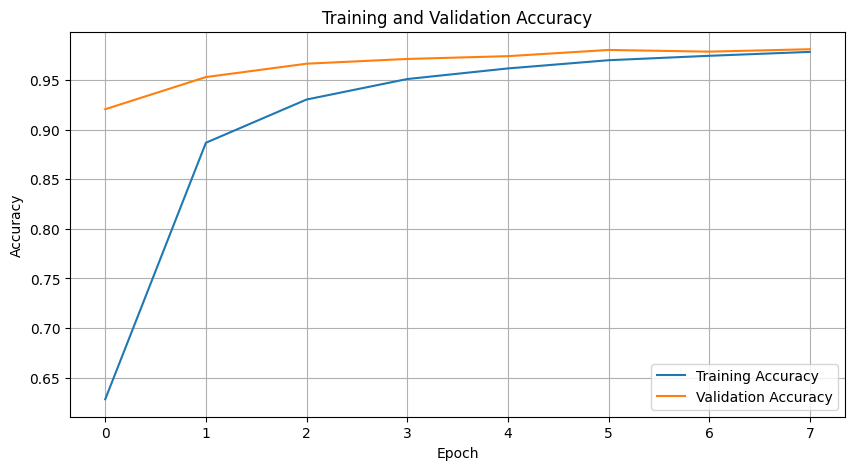

In [ ]:
import matplotlib.pyplot as plt

# Extract history from the tuple
history = histories 

# Plotting accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import tensorflow as tf

# Re-load datasets to get the test_ds and confirm class_names
_, _, test_ds, class_names_reloaded, _ = load_datasets()

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nFinal Model Accuracy on Test Set: {test_acc:.4f}")
print(f"Final Model Loss on Test Set: {test_loss:.4f}")
print("Class names (from re-loaded dataset):", class_names_reloaded)

Found 54318 files belonging to 38 classes.
Using 38023 files for training.
Found 54318 files belonging to 38 classes.
Using 16295 files for validation.
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato__

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get predictions on test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print metrics
print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print("=" * 60)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

MODEL EVALUATION METRICS
Accuracy:  0.9853 (98.53%)
Precision: 0.9860 (98.60%)
Recall:    0.9853 (98.53%)
F1-Score:  0.9851 (98.51%)

Detailed Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.98        92
                                 Apple___Black_rot       1.00      1.00      1.00        98
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        40
                                   Apple___healthy       0.98      1.00      0.99       252
                               Blueberry___healthy       1.00      1.00      1.00       215
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       182
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       131
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.99      0.80      0.88        85
     

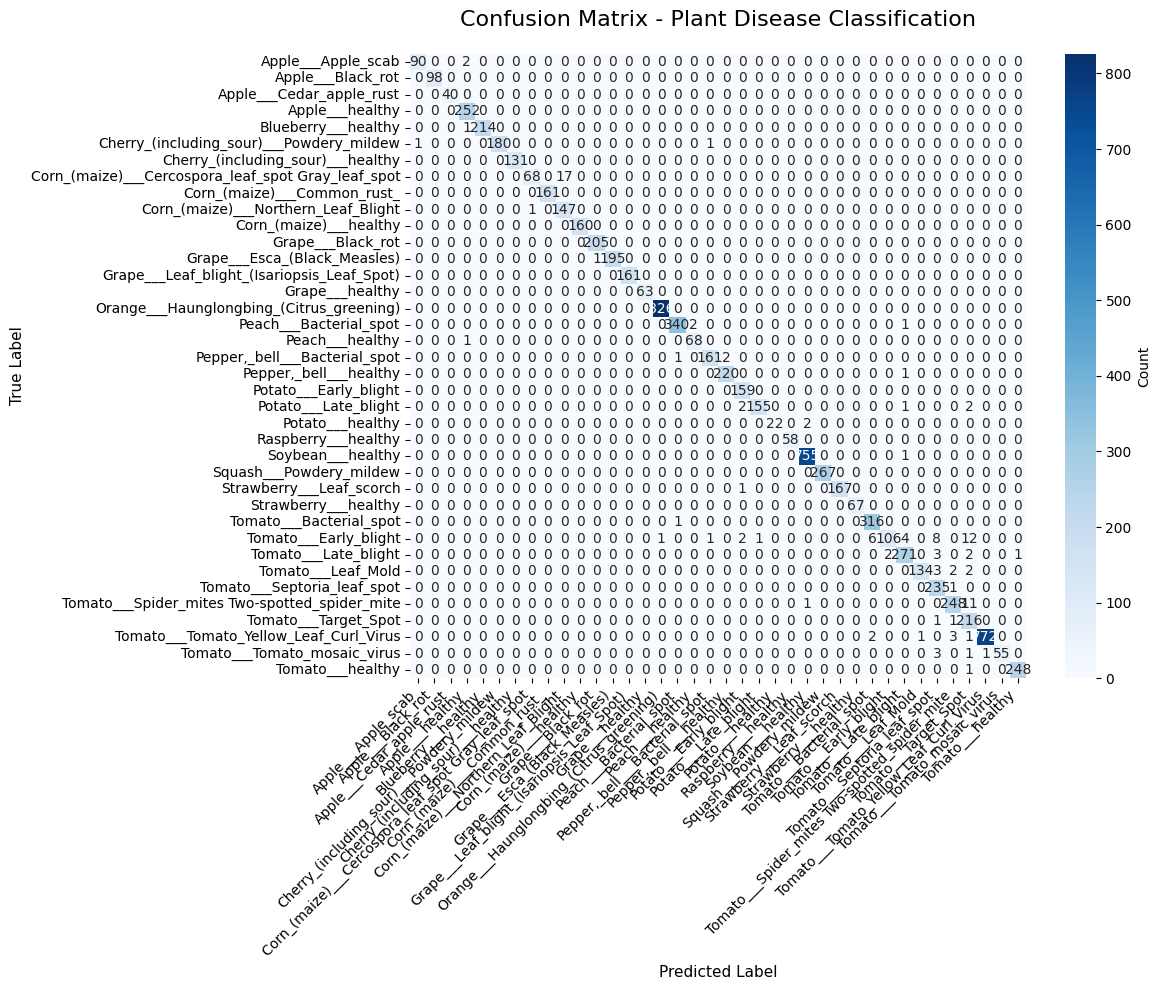

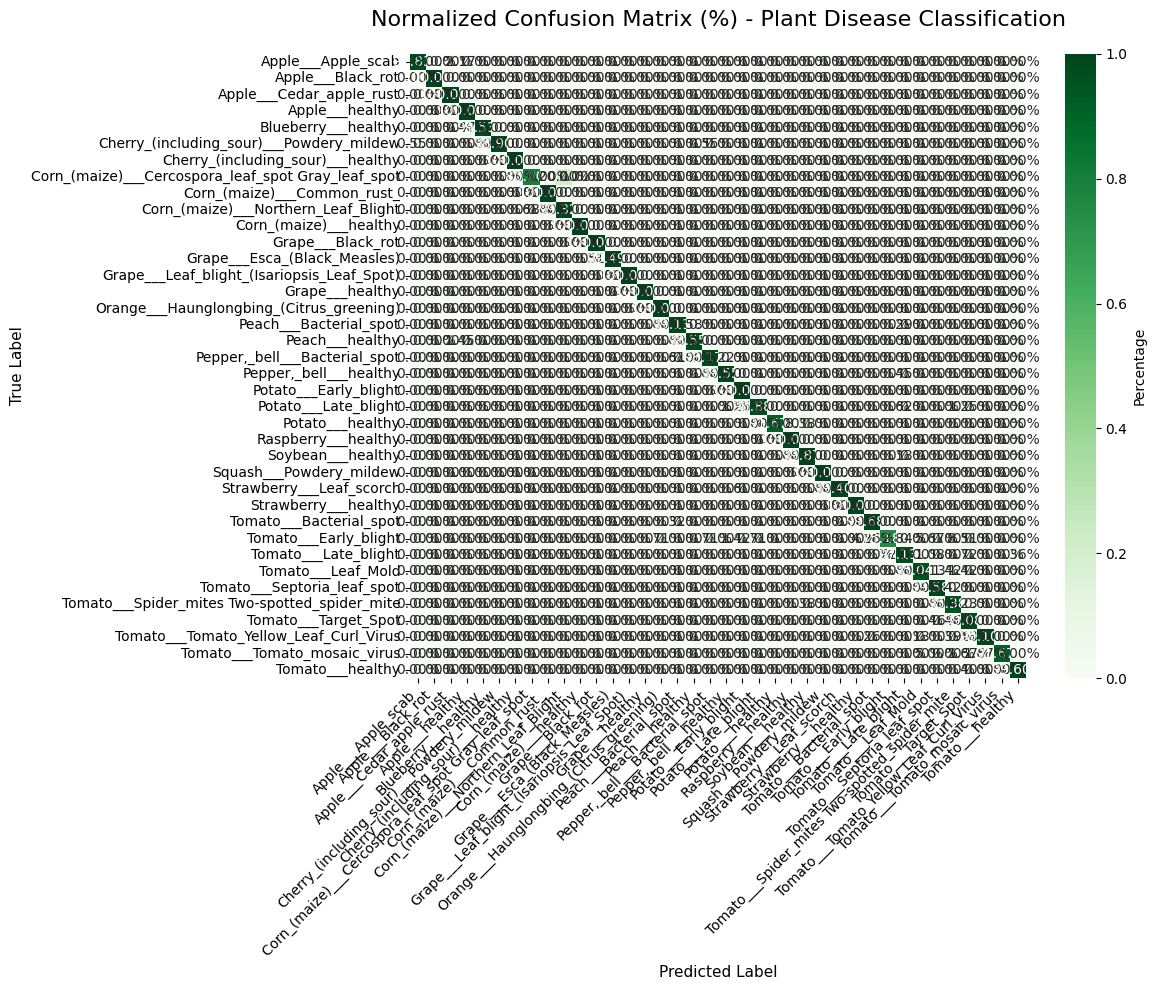

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Plant Disease Classification', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix (%) - Plant Disease Classification', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()